In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

In [68]:
# === SETTINGS ===
ID = "A1"  # Station ID

# === File Paths ===
dir_path = Path.cwd()  # current working directory
print("Current working directory:", dir_path)

# Radiances before correction
rad_dir = dir_path.parent / "results"

# Automatically find the latest (or 'only) file for the given station
SST_files = sorted(rad_dir.glob(f"*{ID}_17_IR_SST.csv"))
SST_file = SST_files[0]

# Extract date string from filename
date_str = SST_file.name.split(f"{ID}_17")[0].rstrip("_")

# === Debug output (optional) ===
print("Data directory:", rad_dir)
print("Averaged SST uncorrected file:", SST_file)
print("\nDate of station:", date_str)

Current working directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/map_IR
Data directory: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/results
Averaged SST uncorrected file: /Users/dimonroy/Library/Mobile Documents/com~apple~CloudDocs/UP_Clouds/SST_RS_Meteor_2025/Infrared_cameras/results/20250626_A1_17_IR_SST.csv

Date of station: 20250626


In [70]:
# === Load water and sky data ===
df_SST = pd.read_csv(SST_file, sep=";", decimal=",")

# Remove white spaces from the columns titles
df_SST.columns = df_SST.columns.str.strip() 

df_SST

,"Time,SST (°C),y_clipped,y_ewma_fb,y_remove_outliers"
0,"2025-06-26 07:20:00,23.01994387308281,23.01994..."
1,"2025-06-26 07:20:01,23.13697898402353,23.13697..."
2,"2025-06-26 07:20:02,23.136365706179447,23.1363..."
3,"2025-06-26 07:20:03,23.081944776282,23.0819447..."
4,"2025-06-26 07:20:04,23.083073273775597,23.0830..."
...,...
46796,"2025-06-26 20:19:56,23.1576095392453,23.157609..."
46797,"2025-06-26 20:19:57,23.081919553855585,23.0819..."
46798,"2025-06-26 20:19:58,23.19688323850687,23.19688..."
46799,"2025-06-26 20:19:59,23.111243415208605,23.1112..."


/opt/anaconda3/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  r

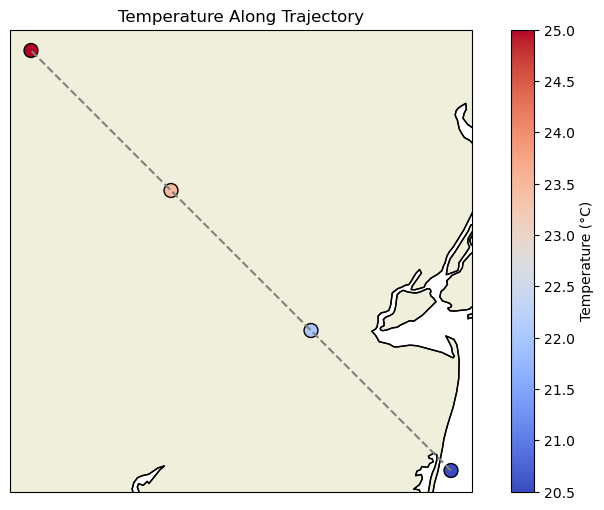

In [ ]:

# Sample data
lats = [40.0, 40.5, 41.0, 41.5]
lons = [-74.0, -74.5, -75.0, -75.5]
temps = [20.5, 22.0, 23.5, 25.0]  # °C

# Plotting
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, edgecolor='black')

# Scatter with colormap
sc = plt.scatter(lons, lats, c=temps, cmap='coolwarm', s=100, edgecolors='black', transform=ccrs.PlateCarree())
plt.plot(lons, lats, color='gray', linestyle='--', transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(sc, orientation='vertical', label='Temperature (°C)')

# Labels
plt.title("Temperature Along Trajectory")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
